In [27]:
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd

data_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(data_url , sep=";")

features = df.drop("quality",axis=1)
label = df["quality"]

split = StratifiedShuffleSplit(n_splits=1 , test_size=0.2 , random_state=42) # Define karta hai ki data ko kaise split karna hai !!

for train_index , test_index in split.split(features,label):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]



In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
exploration_set = strat_train_set.copy()

In [30]:
exploration_set.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1542,6.7,0.855,0.02,1.9,0.064,29.0,38.0,0.99472,3.30,0.56,10.75,6
1558,6.9,0.630,0.33,6.7,0.235,66.0,115.0,0.99787,3.22,0.56,9.50,5
344,11.9,0.570,0.50,2.6,0.082,6.0,32.0,1.00060,3.12,0.78,10.70,6
924,8.6,0.470,0.27,2.3,0.055,14.0,28.0,0.99516,3.18,0.80,11.20,5
971,10.4,0.260,0.48,1.9,0.066,6.0,10.0,0.99724,3.33,0.87,10.90,6


### Scatter Visualization

<Axes: xlabel='fixed acidity', ylabel='density'>

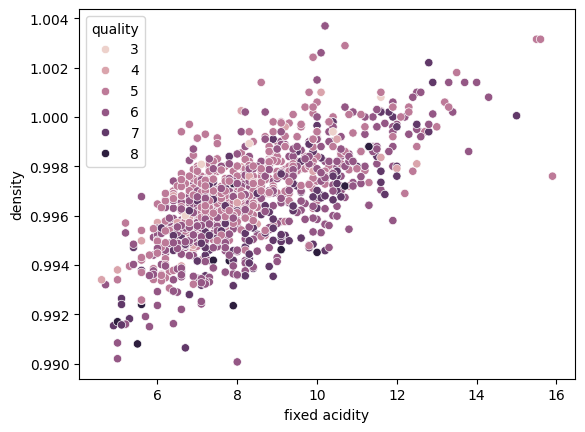

In [31]:
# Using Seaborn

sns.scatterplot(x="fixed acidity" , y="density" , hue="quality" , data=exploration_set)

<Axes: xlabel='fixed acidity', ylabel='density'>

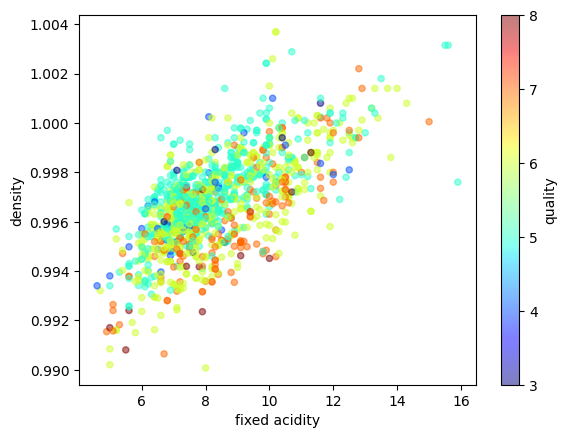

In [32]:
# Using Matplotlib.pyplot

exploration_set.plot(kind="scatter" , x="fixed acidity" , y="density" , alpha=0.5 , c="quality" , cmap=plt.get_cmap("jet"))

### Relation Between Features : correlation matrix

In [33]:
corr_matrix = exploration_set.corr()
corr_matrix

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.247712,0.662363,0.120815,0.093881,-0.123203,-0.088770,0.668990,-0.674780,0.177493,-0.059853,0.107940
volatile acidity,-0.247712,1.000000,-0.543362,-0.002826,0.048699,-0.012979,0.065962,0.026262,0.232789,-0.257722,-0.205491,-0.383249
citric acid,0.662363,-0.543362,1.000000,0.170988,0.225691,-0.032409,0.070900,0.363450,-0.546526,0.312819,0.107308,0.210802
residual sugar,0.120815,-0.002826,0.170988,1.000000,0.050461,0.186637,0.214147,0.343316,-0.091494,0.003743,0.052004,0.003710
chlorides,0.093881,0.048699,0.225691,0.050461,1.000000,0.005071,0.049451,0.195681,-0.287841,0.403491,-0.230659,-0.120231
free sulfur dioxide,-0.123203,-0.012979,-0.032409,0.186637,0.005071,1.000000,0.657639,0.009101,0.051275,0.055357,-0.085068,-0.048291
total sulfur dioxide,-0.088770,0.065962,0.070900,0.214147,0.049451,0.657639,1.000000,0.090877,-0.103004,0.056656,-0.224324,-0.194511
density,0.668990,0.026262,0.363450,0.343316,0.195681,0.009101,0.090877,1.000000,-0.347765,0.148025,-0.509323,-0.193009
pH,-0.674780,0.232789,-0.546526,-0.091494,-0.287841,0.051275,-0.103004,-0.347765,1.000000,-0.229115,0.211668,-0.052063
sulphates,0.177493,-0.257722,0.312819,0.003743,0.403491,0.055357,0.056656,0.148025,-0.229115,1.000000,0.077041,0.228050


In [34]:
corr_matrix["quality"]

fixed acidity           0.107940
volatile acidity       -0.383249
citric acid             0.210802
residual sugar          0.003710
chlorides              -0.120231
free sulfur dioxide    -0.048291
total sulfur dioxide   -0.194511
density                -0.193009
pH                     -0.052063
sulphates               0.228050
alcohol                 0.481197
quality                 1.000000
Name: quality, dtype: float64

### Visualize Correlation matrix with heat-map

<Axes: >

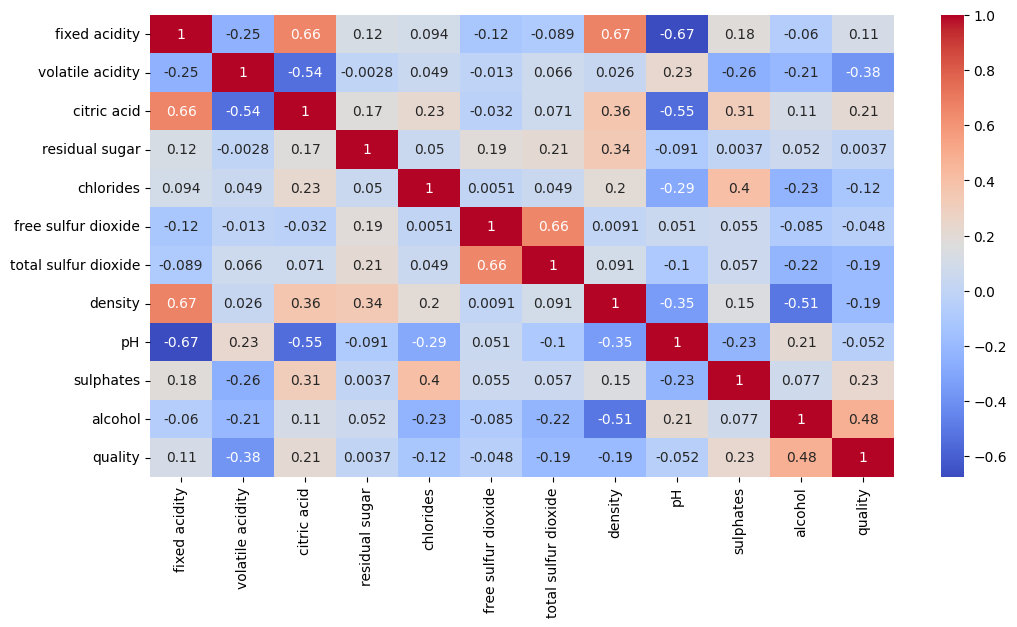

In [35]:
plt.figure(figsize=(12,6))
sns.heatmap(corr_matrix , annot=True , cmap="coolwarm")

### Scatter Matrix

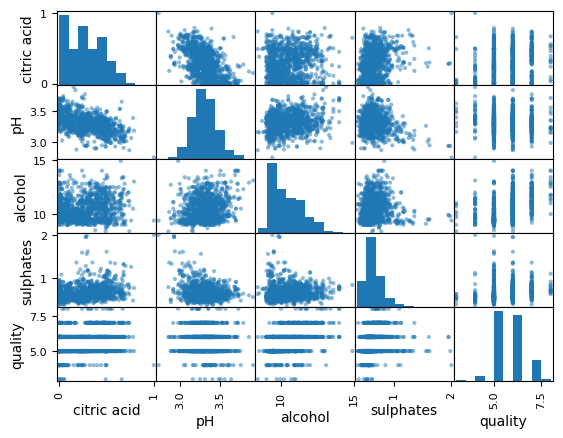

In [46]:
from pandas.plotting import scatter_matrix

attribute_list = ['citric acid' , 'pH' , 'alcohol' , 'sulphates' , 'quality']
scatter_matrix(exploration_set[attribute_list])
plt.show()